The notebook focused on text clustering using various embedding techniques. The dataset we are using is the 20newsgroups dataset with 3 categories. The goal is to compare several embedding approaches such as sentence transformers, GloVe, TF-IDF, and BERT-CLS, and cluster the resulting embeddings. This comparison can help to determine which approach provides the best clustering performance for the given dataset.

To achieve this, we have taken several steps. First, we have preprocessed the text data and converted it into numerical representations using the different embedding approaches. Next, we have applied clustering algorithms to the resulting embeddings to group the documents into clusters. Finally, you have compared the performance of the different embedding approaches by evaluating the quality of the resulting clusters using relevant metrics such as silhouette score or purity.

By comparing the different embedding approaches, we can gain insights into which technique is most effective for clustering text data in general, and for the 20newsgroups dataset in particular. This information can be valuable for future projects involving text clustering, as it can inform the selection of the most appropriate embedding approach for a given dataset and task.

In [1]:
from sentence_transformers import SentenceTransformer
import torch
from transformers import BertTokenizer, BertModel
import time

from torchtext.vocab import GloVe

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, BisectingKMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score
from sklearn.decomposition import PCA

from gensim.models import KeyedVectors

import pandas as pd
import numpy as np


import re
import string
import nltk
from nltk.corpus import stopwords

# viz libs
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

import ssl
import nltk

try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('stopwords')
nltk.download('punkt_tab')

c:\Users\Nurzhan\miniconda3\envs\politech2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nurzhan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Nurzhan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Nurzhan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [3]:

categories = [
 'biology',
 'cooking',
 'diy',
 'robotics',
 'travel',
 'cryptography'
]

df1 = pd.read_csv('biology.csv')
df2 = pd.read_csv('cooking.csv')
df3 = pd.read_csv('diy.csv')
df4 = pd.read_csv('robotics.csv')
df5 = pd.read_csv('travel.csv')
df6 = pd.read_csv('crypto.csv')

df1['target'] = 0
df2['target'] = 1
df3['target'] = 2
df4['target'] = 3
df5['target'] = 4
df6['target'] = 5

df1 = df1.iloc[0:1000]
df2 = df2.iloc[0:1000]
df3 = df3.iloc[0:1000]
df4 = df4.iloc[0:1000]
df5 = df5.iloc[0:1000]
df6 = df6.iloc[0:1000]

#df = pd.concat([df1, df2, df3, df4, df5, df6])
df = pd.concat([df1, df2, df3, df4, df5, df6])


In [4]:
def preprocess_text(text: str) -> str:
    # remove links
    text = re.sub(r"http\S+", "", text)
    # remove special chars and numbers
    text = re.sub("[^A-Za-z]+", " ", text)
    
    # remove stopwords
    tokens = nltk.word_tokenize(text)
    tokens = [w for w in tokens if not w.lower() in stopwords.words("english")]
    text = " ".join(tokens)
    text = text.lower().strip()
    
    return text

In [5]:
from tqdm import tqdm
tqdm.pandas()

df['text_cleaned'] = df['content'].progress_apply(lambda text: preprocess_text(text))
df = df[df['text_cleaned'] != '']

  7%|▋         | 442/6000 [00:16<03:28, 26.70it/s]


KeyboardInterrupt: 

In [6]:
df['len_words'] =  df['text_cleaned'].apply(lambda sentence: len(sentence.split()))

In [7]:
df['len_words'].describe()

count    6000.000000
mean       63.627333
std        70.371984
min         4.000000
25%        28.000000
50%        46.000000
75%        77.000000
max      2418.000000
Name: len_words, dtype: float64

### TF-IDF Vectorization

This is a simple but effective method for generating vector representations of sentences. It stands for "term frequency-inverse document frequency" and it calculates the importance of words in a sentence by taking into account how often they appear in the sentence and how rare they are in the entire corpus of sentences. 



In [8]:
vectorizer = TfidfVectorizer(sublinear_tf=True, min_df=5, max_df=0.95)
X = vectorizer.fit_transform(df['text_cleaned']).toarray()

Cluster 0 refers to sport, cluster 2 to software / tech, cluster 3 to religion

### Sentence Transformer
Sentence Transformers are deep learning models that can encode natural language sentences into high-dimensional vector representations. They are trained using a pre-training and fine-tuning approach and have achieved state-of-the-art performance on several natural language processing tasks. These models are widely used for various applications such as chatbots, search engines, and recommendation systems.

In [ ]:
tqdm.pandas()

st = time.time()

model = SentenceTransformer('Qwen/Qwen3-Embedding-0.6B', device='mps')
df['encode_transforemers'] = df['text_cleaned'].progress_apply(lambda text: model.encode(text, convert_to_numpy=True).flatten())

et = time.time()

print("Elapsed time: {:.2f} seconds".format(et - st))

 10%|▉         | 593/6000 [01:22<12:34,  7.16it/s]


KeyboardInterrupt: 

: 

In [ ]:
# Check that MPS is available
if not torch.backends.mps.is_available():
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

else:
    mps_device = torch.device("mps")

    # Create a Tensor directly on the mps device
    x = torch.ones(5, device=mps_device)

    # Move your model to mps just like any other device
    model.to(mps_device)

In [ ]:
X_transformers = np.vstack(df['encode_transforemers'])

### Glove

GloVe is a word embedding technique that represents words as dense vectors in a high-dimensional space. It captures both local and global context, making it useful for various tasks. To cluster sentences using GloVe, one approach is to concatenate the word vectors in a sentence, form a matrix, and then apply a clustering algorithm such as k-means. The resulting clusters can reveal common themes or patterns in the data.

In [ ]:
embeddings = GloVe(name='6B', dim=100)

In [ ]:
# Set the maximum sentence length and embedding dimension
max_length = 100 
embedding_dim = 100

# define a function to convert a sentence to a fixed-size vector using GloVe embeddings
def sentence_embedding(sentence):
    words = sentence.split()
    num_words = min(len(words), max_length)
    embedding_sentence = np.zeros((max_length, embedding_dim))
    
    for i in range(num_words):
        word = words[i]
        if word in embeddings.stoi:
            embedding_sentence[i] = embeddings.vectors[embeddings.stoi[word]]
            
    return embedding_sentence.flatten()

In [ ]:
tqdm.pandas()
df['encode_glove'] = df['text_cleaned'].progress_apply(lambda sentence: sentence_embedding(sentence))

100%|██████████| 6000/6000 [00:00<00:00, 7579.88it/s]


In [ ]:
X_glove = np.vstack(df['encode_glove'])

### BERT - [CLS] token for sentnce context

BERT, is a pre-trained deep learning model that can be fine-tuned for various natural language processing tasks. One of the main innovations of BERT is its ability to represent both the left and right context of a word, allowing it to better capture the meaning of a sentence.

In BERT, the [CLS] token, which stands for "classification", is a special token that is inserted at the beginning of every input sequence. During pre-training, BERT is trained to predict the correct class label for the entire sequence based on the [CLS] token representation, which is meant to capture the overall meaning of the sequence.

In [ ]:
# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

In [ ]:
def get_cls_sentence(sentence):
    # Tokenize input sentence and convert to tensor
    input_ids = torch.tensor([tokenizer.encode(sentence, add_special_tokens=True, max_length=512)])

    # Pass input through BERT model and extract embeddings for [CLS] token
    with torch.no_grad():
        outputs = model(input_ids)
        cls_embedding = outputs[0][:, 0, :]
    
    return cls_embedding.flatten()

In [ ]:
st = time.time()
tqdm.pandas()
df['cls_bert'] = df['text_cleaned'].progress_apply(lambda sentence: get_cls_sentence(sentence))

et = time.time()

print("Elapsed time: {:.2f} seconds".format(et - st))

100%|██████████| 6000/6000 [02:52<00:00, 34.86it/s]

Elapsed time: 172.12 seconds


In [ ]:
X_cls_bert = np.vstack(df['cls_bert'])

In [ ]:
df[df['target'] == 2]['text_cleaned'].value_counts()

text_cleaned
p looking finish basement simply want wall concrete blocks make wall want insulate well becomes usable family room done go installing wall given wooden beams ceiling concrete floor p                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                1
p fluorescent lights office someone said ballast bad replace ballast p                                                                                                                                                                                                                             

### Clustering
#### 1. K-Means

To evaluate the performance of a clustering algorithm like k-means, we use various metrics that compare the predicted clusters to the ground truth labels. Here are a few common metrics:

Adjusted Rand Index (ARI): measures the similarity between the predicted clusters and the ground truth labels, taking into account chance agreement. ARI ranges from -1 to 1, where 1 indicates perfect agreement and 0 indicates random clustering.

Normalized Mutual Information (NMI): measures the mutual information between the predicted clusters and the ground truth labels, normalized by the entropy of the clusters and labels. NMI ranges from 0 to 1, where 1 indicates perfect agreement.

Fowlkes-Mallows Index (FMI): measures the geometric mean of the precision and recall of the predicted clusters with respect to the ground truth labels. FMI ranges from 0 to 1, where 1 indicates perfect agreement.

In [ ]:
def eval_cluster(embedding, kmeans):
    y_pred = kmeans.fit_predict(embedding)
    
    # Evaluate the performance using ARI, NMI, and FMI
    ari = adjusted_rand_score(df["target"], y_pred)
    nmi = normalized_mutual_info_score(df["target"], y_pred)
    fmi = fowlkes_mallows_score(df["target"], y_pred)

    # Print Metrics scores
    print("Adjusted Rand Index (ARI): {:.3f}".format(ari))
    print("Normalized Mutual Information (NMI): {:.3f}".format(nmi))
    print("Fowlkes-Mallows Index (FMI): {:.3f}".format(fmi))

In [ ]:
def dimension_reduction(embedding, method):

    pca = PCA(n_components=2, random_state=42)

    pca_vecs = pca.fit_transform(embedding)

    # save our two dimensions into x0 and x1
    x0 = pca_vecs[:, 0]
    x1 = pca_vecs[:, 1]
    
    df[f'x0_{method}'] = x0 
    df[f'x1_{method}'] = x1 
    

In [ ]:
def plot_pca(x0_name, x1_name, cluster_name, method):

    plt.figure(figsize=(12, 7))

    plt.title(f"TF-IDF + KMeans 20newsgroup clustering with {method}", fontdict={"fontsize": 18})
    plt.xlabel("X0", fontdict={"fontsize": 16})
    plt.ylabel("X1", fontdict={"fontsize": 16})

    sns.scatterplot(data=df, x=x0_name, y=x1_name, hue=cluster_name, palette="viridis")
    plt.show()

Adjusted Rand Index (ARI): 0.660
Normalized Mutual Information (NMI): 0.688
Fowlkes-Mallows Index (FMI): 0.719


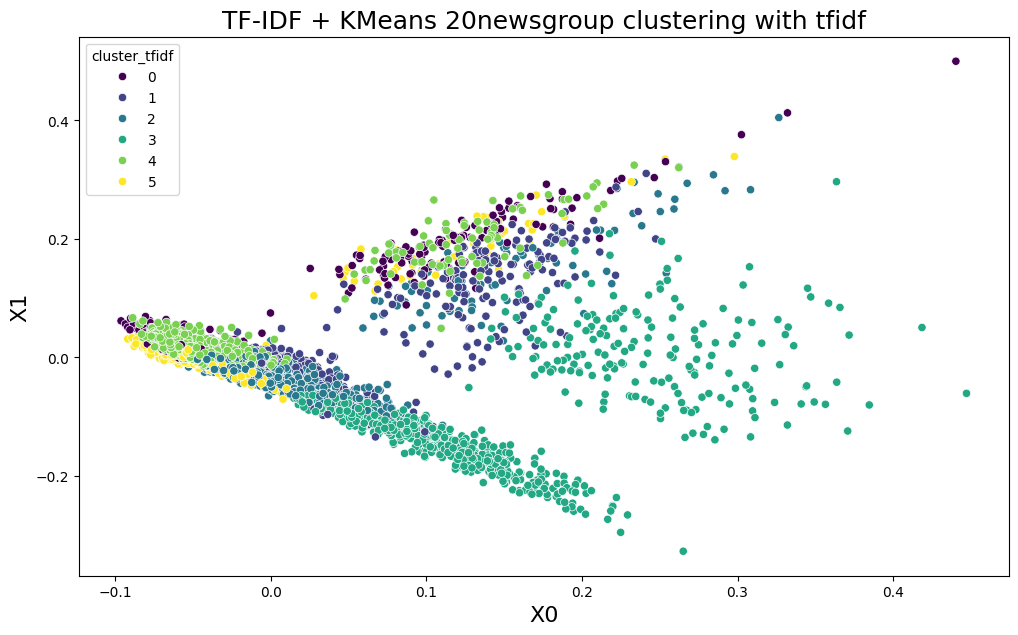

Adjusted Rand Index (ARI): 0.709
Normalized Mutual Information (NMI): 0.797
Fowlkes-Mallows Index (FMI): 0.767


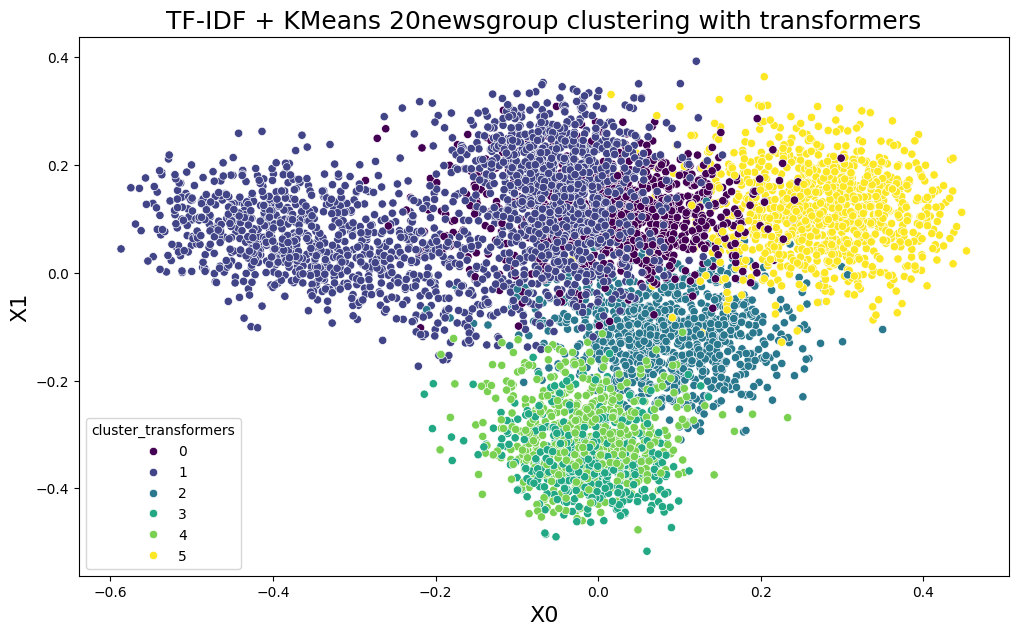

Adjusted Rand Index (ARI): 0.036
Normalized Mutual Information (NMI): 0.049
Fowlkes-Mallows Index (FMI): 0.235


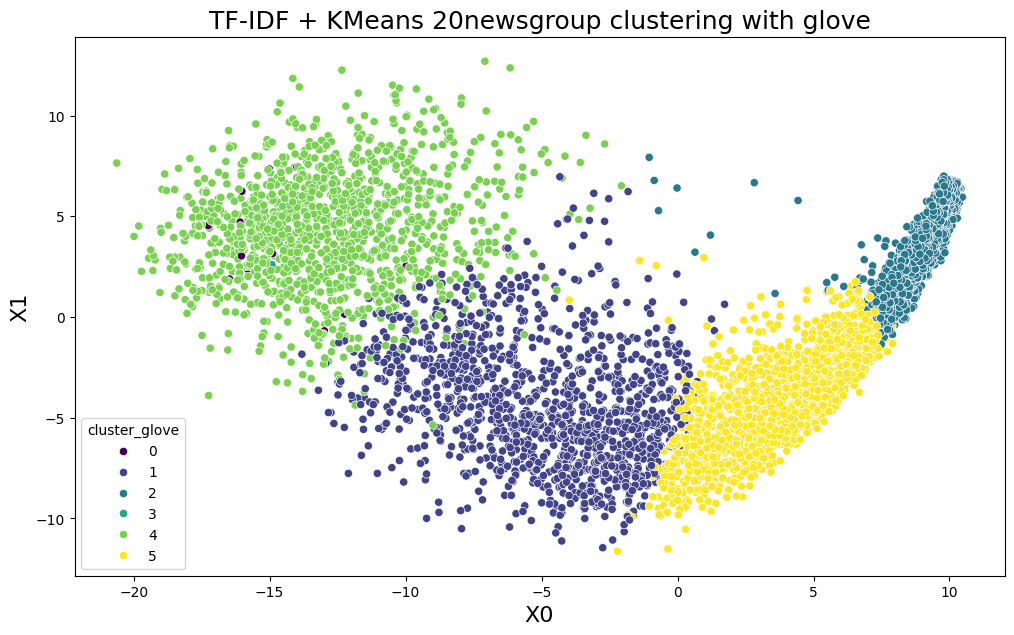

In [ ]:
for embedding_and_method in [(X, 'tfidf'), (X_transformers, 'transformers'), (X_glove, 'glove') ]:
    embedding, method = embedding_and_method[0], embedding_and_method[1]
    
    # initialize kmeans with 3 centroids
    #kmeans = KMeans(n_clusters=6, random_state=42)
    kmeans = KMeans(n_clusters=6, random_state=42)
    # fit the model
    kmeans.fit(embedding)

    # store cluster labels in a variable
    clusters = kmeans.labels_

    # Assign clusters to our dataframe
    clusters_result_name = f'cluster_{method}'
    df[clusters_result_name] = clusters
    
    eval_cluster(embedding, kmeans)
    
    dimension_reduction(embedding, method)
    
    plot_pca(f'x0_{method}', f'x1_{method}', cluster_name=clusters_result_name, method=method)

In [ ]:
df

,id,title,content,tags,target,text_cleaned,len_words,encode_transforemers,encode_glove,cls_bert,cluster_tfidf,x0_tfidf,x1_tfidf,cluster_transformers,x0_transformers,x1_transformers,cluster_glove,x0_glove,x1_glove
0,1,What is the criticality of the ribosome bindin...,"<p>In prokaryotic translation, how critical fo...",ribosome binding-sites translation synthetic-b...,0,p prokaryotic translation critical efficient t...,27,"[0.06560293, -0.090499274, 0.015794395, -0.019...","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.9406), tensor(0.0667), tensor(0.157...",2,-0.047490,0.000383,2,0.039670,-0.105809,2,7.858146,1.883441
1,2,How is RNAse contamination in RNA based experi...,<p>Does anyone have any suggestions to prevent...,rna biochemistry,0,p anyone suggestions prevent rnase contaminati...,25,"[0.023906827, -0.005491035, 0.0058802594, 1.58...","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.5140), tensor(0.3523), tensor(0.216...",5,-0.060693,0.014561,2,0.189128,-0.017652,2,8.973827,3.760314
2,3,Are lymphocyte sizes clustered in two groups?,<p>Tortora writes in <em>Principles of Anatomy...,immunology cell-biology hematology,0,p tortora writes em principles anatomy physiol...,35,"[-0.01661632, -0.11549825, 0.016361352, 0.0154...","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.4239), tensor(0.1435), tensor(0.567...",2,-0.009722,-0.029904,2,0.064665,-0.161649,5,5.906114,-1.207336
3,4,How long does antibiotic-dosed LB maintain goo...,<p>Various people in our lab will prepare a li...,cell-culture,0,p various people lab prepare liter lb add kana...,48,"[0.01610325, -0.023698159, -0.006022375, -0.01...","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.3280), tensor(0.2570), tensor(0.289...",5,-0.047673,-0.001564,5,0.202378,0.025130,5,3.273367,-3.780167
4,5,Is exon order always preserved in splicing?,<p>Are there any cases in which the splicing m...,splicing mrna spliceosome introns exons,0,p cases splicing machinery constructs mrna exo...,17,"[0.0023097983, -0.07467832, 0.0039345785, 0.02...","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.7076), tensor(0.1288), tensor(-0.13...",2,-0.040416,-0.006932,2,0.100068,-0.202720,2,9.710212,6.172969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3535,Is any decent RNG acceptable as a stream cipher?,"<p>I have a function f(x,n) that takes a 128-b...",random-number-generator stream-cipher,5,p function f x n takes bit key x generates n b...,84,"[0.015126731, -0.01806786, 0.00015691324, 0.00...","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.4048), tensor(0.3732), tensor(-0.07...",3,0.087438,-0.124798,3,-0.007372,-0.425706,4,-9.403000,3.849287
996,3539,The security of data traffic over both SSTP & SSL,<p>Suppose you're connected to a VPN server vi...,tls sstp,5,p suppose connected vpn server via sstp vpn tr...,72,"[-0.012211161, -0.052875936, 0.009113748, 0.04...","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.6120), tensor(-0.0426), tensor(0.07...",3,0.049045,-0.090672,3,-0.038630,-0.200815,1,-3.753040,-0.394305
997,3540,What is the actual difference between security...,"<p>In an <strong>abstract</strong> sense, aren...",encryption keys,5,p strong abstract strong sense p p definitions...,81,"[-0.014547004, -0.006058249, 0.0135963755, -0....","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.4065), tensor(0.4556), tensor(0.248...",3,0.242569,0.033016,3,-0.006666,-0.426809,1,-8.021257,-0.953115
998,3549,Common modulus attack on RSA when the 2 public...,<p>This is an exam question an i have no idea ...,rsa chosen-ciphertext-attack,5,p exam question idea recover message p p john ...,118,"[0.00939726, -0.02115786, 0.008230729, 0.04605...","[-0.6517000198364258, 0.8048400282859802, 0.04...","[tensor(-0.6612), tensor(0.3081), tensor(0.027...",3,0.139156,-0.174671,4,-0.026827,-0.388449,4,-14.523417,5.497095


### PCA & Vizualization